# Structure Generation Debug Notebook v2.0

This notebook previews generated structures using the same PyBullet rendering path as `tools/simulator/generator.py`.

- Uses `src.scene.render_front` and `src.scene.render_top`
- Uses `src_v2_0.structures` for the v2.0 structure layout rules
- Keeps `relaxed=True` for stage-1 shape checking
- Prints per-layer counts and tilt metadata alongside rendered images


In [57]:
from pathlib import Path
import importlib
import sys
import traceback
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
SIM_ROOT = ROOT / 'tools' / 'simulator'
if str(SIM_ROOT) not in sys.path:
    sys.path.insert(0, str(SIM_ROOT))

from src.config import SimConfig
import src_v2_0.structures as structures_module
import src_v2_0.preview as preview_module

cfg = SimConfig()

def reload_modules():
    global structures_module, preview_module, list_structures, build_structure_layout_v2, render_structure_preview, CLASS_ORDER
    structures_module = importlib.reload(structures_module)
    preview_module = importlib.reload(preview_module)
    list_structures = structures_module.list_structures
    build_structure_layout_v2 = structures_module.build_structure_layout_v2
    render_structure_preview = preview_module.render_structure_preview
    CLASS_ORDER = list_structures()

reload_modules()

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11


In [58]:
def infer_layers(layout, z_round_digits: int = 4):
    grouped = defaultdict(list)
    for blk in layout:
        z_key = round(float(blk.z), z_round_digits)
        grouped[z_key].append(blk)
    ordered = sorted(grouped.items(), key=lambda item: item[0])
    rows = []
    for idx, (z_key, blocks) in enumerate(ordered):
        xs = [blk.x for blk in blocks]
        ys = [blk.y for blk in blocks]
        rows.append(
            {
                'layer_idx': idx,
                'z_center': z_key,
                'count': len(blocks),
                'x_span': round(max(xs) - min(xs), 4) if xs else 0.0,
                'y_span': round(max(ys) - min(ys), 4) if ys else 0.0,
            }
        )
    return pd.DataFrame(rows)


def generate_layout(structure_label: str, stability_label: str, seed: int = 42, reload_module: bool = True):
    if reload_module:
        reload_modules()
    rng = np.random.default_rng(seed)
    return build_structure_layout_v2(
        rng=rng,
        cfg=cfg,
        structure=structure_label,
        stability_label=stability_label,
        relaxed=True,
    )


def generate_preview(structure_label: str, stability_label: str, seed: int = 42, reload_module: bool = True):
    if reload_module:
        reload_modules()
    return render_structure_preview(
        seed=seed,
        structure=structure_label,
        stability_label=stability_label,
        cfg=cfg,
        relaxed=True,
        gui=False,
    )


def show_layout_debug(structure_label: str, stability_label: str, seed: int = 42):
    preview = generate_preview(structure_label, stability_label, seed=seed, reload_module=True)
    result = preview.structure_result
    layer_df = infer_layers(result.layout)
    print(f'structure: {result.structure_label}')
    print(f'stability: {result.stability_label}')
    print(f'num_blocks: {len(result.layout)}')
    print(f'tilt_axis: {result.tilt_axis}')
    print('tilt_profile:')
    print(result.tilt_profile)
    display(layer_df)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    axes[0].imshow(preview.front_rgb)
    axes[0].set_title(f'{structure_label} | {stability_label} | front')
    axes[0].axis('off')
    axes[1].imshow(preview.top_rgb)
    axes[1].set_title(f'{structure_label} | {stability_label} | top')
    axes[1].axis('off')
    plt.show()
    return result, layer_df, preview


def debug_generate_layout(structure_label: str, stability_label: str, seed: int = 42):
    try:
        return show_layout_debug(structure_label, stability_label, seed=seed)
    except Exception as exc:
        print('generation failed')
        print(f'structure={structure_label}, stability={stability_label}, seed={seed}')
        print(f'error={exc}')
        traceback.print_exc()
        raise


structure: wall
stability: stable
num_blocks: 27
tilt_axis: centered
tilt_profile:
{'segments': [], 'switches': 0, 'mode': 'fixed_wall', 'wall_axis': 'left_right', 'row_pattern': [5, 6, 5, 6, 5], 'shape_rule': '5-6-5-6-5 brick wall'}


,layer_idx,z_center,count,x_span,y_span
0,0,0.084,5,0.980,0.0
1,1,0.257,6,1.205,0.0
2,2,0.430,5,0.980,0.0
3,3,0.603,6,1.205,0.0
4,4,0.776,5,0.980,0.0


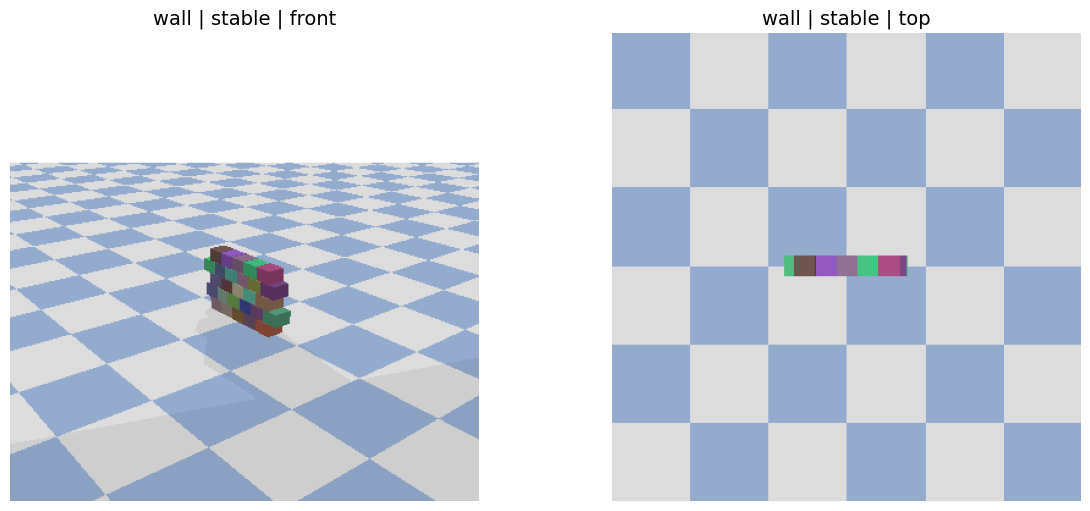

In [59]:
# Quick single-case check
result, layer_df, preview = debug_generate_layout('wall', 'stable', seed=42)

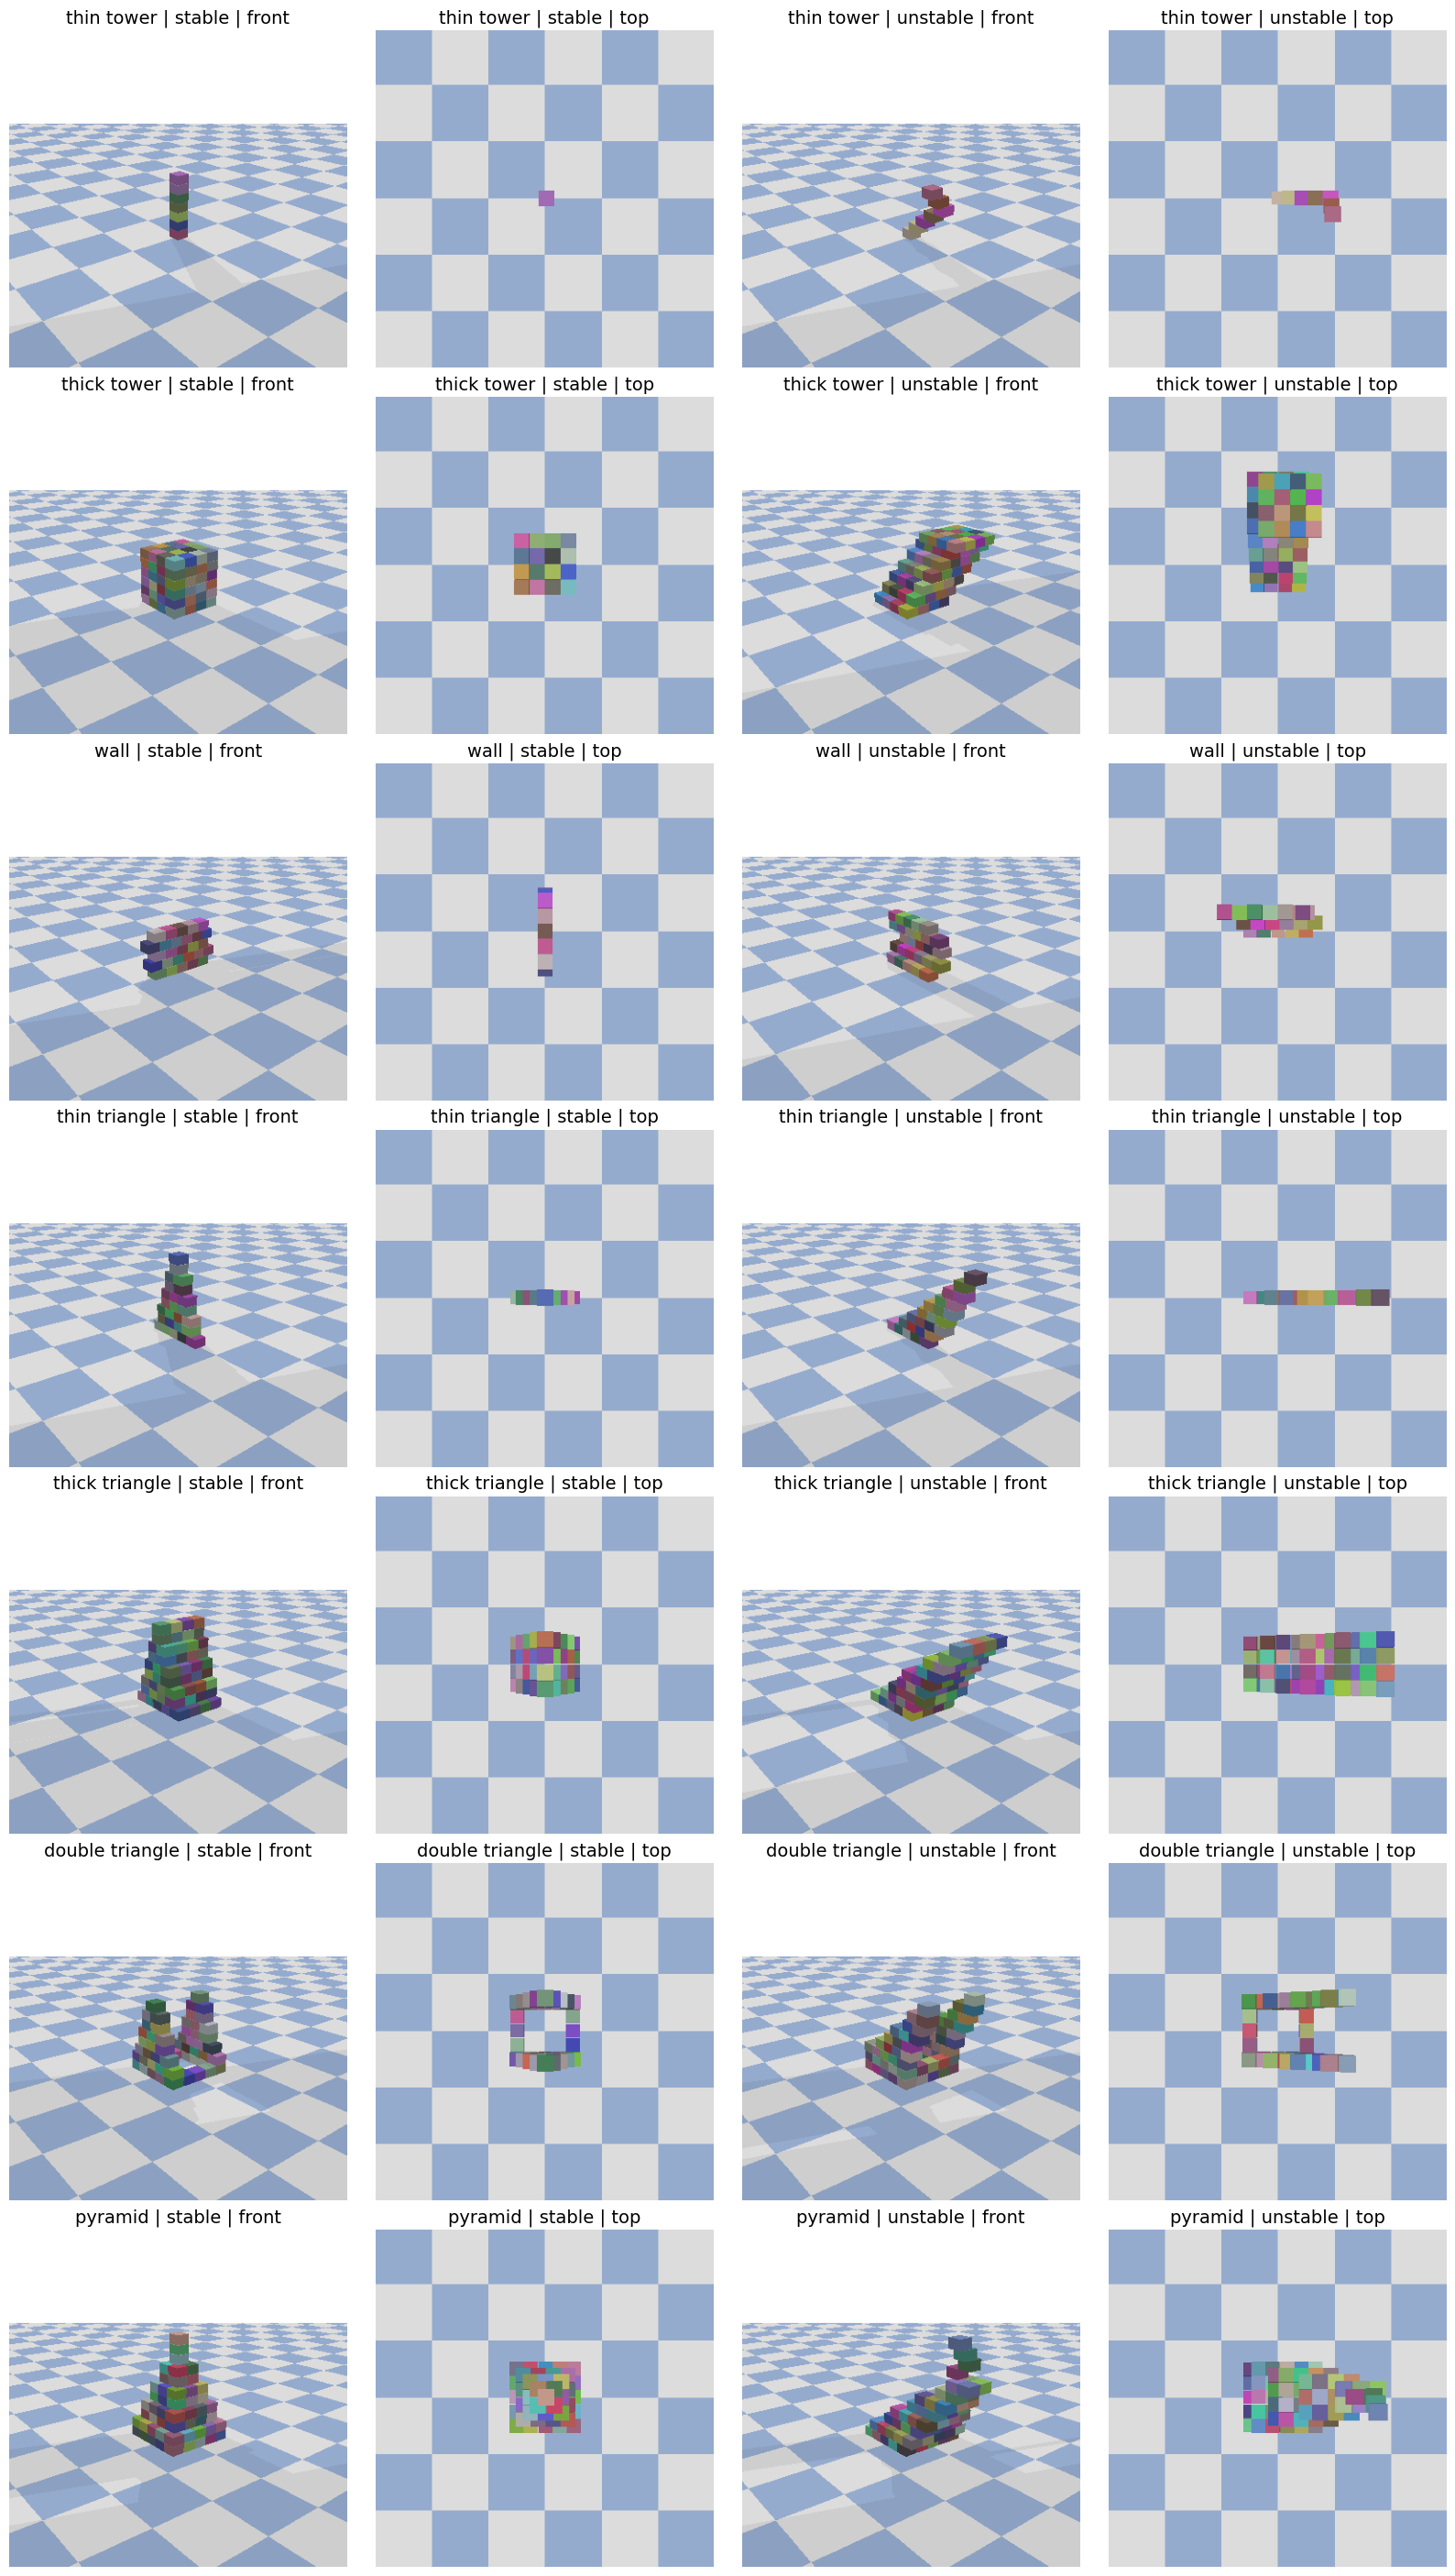

In [60]:
def show_label_grid(seed: int = 42):
    rows = len(CLASS_ORDER)
    fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows), constrained_layout=True)

    for row_idx, structure_label in enumerate(CLASS_ORDER):
        stable_preview = generate_preview(structure_label, 'stable', seed=seed + row_idx, reload_module=(row_idx == 0))
        unstable_preview = generate_preview(structure_label, 'unstable', seed=seed + 100 + row_idx, reload_module=False)

        axes[row_idx, 0].imshow(stable_preview.front_rgb)
        axes[row_idx, 0].set_title(f'{structure_label} | stable | front')
        axes[row_idx, 0].axis('off')

        axes[row_idx, 1].imshow(stable_preview.top_rgb)
        axes[row_idx, 1].set_title(f'{structure_label} | stable | top')
        axes[row_idx, 1].axis('off')

        axes[row_idx, 2].imshow(unstable_preview.front_rgb)
        axes[row_idx, 2].set_title(f'{structure_label} | unstable | front')
        axes[row_idx, 2].axis('off')

        axes[row_idx, 3].imshow(unstable_preview.top_rgb)
        axes[row_idx, 3].set_title(f'{structure_label} | unstable | top')
        axes[row_idx, 3].axis('off')

    plt.show()


show_label_grid(seed=42)

In [61]:
def summarize_case(structure_label: str, stability_label: str, seed: int):
    result = generate_layout(structure_label, stability_label, seed=seed)
    layer_df = infer_layers(result.layout)
    return {
        'structure_label': structure_label,
        'stability_label': stability_label,
        'seed': seed,
        'num_blocks': len(result.layout),
        'num_layers': len(layer_df),
        'layer_counts': layer_df['count'].tolist(),
        'tilt_axis': result.tilt_axis,
    }


summary_rows = []
for structure_label in CLASS_ORDER:
    for stability_label in ['stable', 'unstable']:
        summary_rows.append(summarize_case(structure_label, stability_label, seed=42))

summary_df = pd.DataFrame(summary_rows)
summary_df


,structure_label,stability_label,seed,num_blocks,num_layers,layer_counts,tilt_axis
0,thin tower,stable,42,7,7,"[1, 1, 1, 1, 1, 1, 1]",diag_neg
1,thin tower,unstable,42,7,7,"[1, 1, 1, 1, 1, 1, 1]",diag_neg
2,thick tower,stable,42,80,5,"[16, 16, 16, 16, 16]",diag_neg
3,thick tower,unstable,42,80,5,"[16, 16, 16, 16, 16]",diag_neg
4,wall,stable,42,27,5,"[5, 6, 5, 6, 5]",centered
5,wall,unstable,42,27,5,"[5, 6, 5, 6, 5]",front_back
6,thin triangle,stable,42,20,7,"[5, 4, 3, 3, 2, 2, 1]",centered
7,thin triangle,unstable,42,20,7,"[5, 4, 3, 3, 2, 2, 1]",left_right
8,thick triangle,stable,42,75,9,"[15, 12, 12, 9, 9, 6, 6, 3, 3]",centered
9,thick triangle,unstable,42,75,9,"[15, 12, 12, 9, 9, 6, 6, 3, 3]",left_right


In [62]:
EXPECTED_RULE_HINTS = {
    'thick tower': 'expect repeated 4x4 layers',
    'wall': 'expect 5-6-5-6-5 brick wall pattern',
    'thin triangle': 'expect 5-4-3-3-2-2-1 layer counts with thickness 1',
    'thick triangle': 'expect triangle layers with thickness 3 or 4',
    'double triangle': 'expect two parallel thin triangles with a square-like base footprint',
    'pyramid': 'expect 5x5,5x5,4x4,4x4,3x3,3x3,2x2,2x2 then thin wall on top',
}

for structure_label in CLASS_ORDER:
    print(structure_label)
    print('  ', EXPECTED_RULE_HINTS.get(structure_label, 'manual visual check'))
    for stability_label in ['stable', 'unstable']:
        row = summary_df[
            (summary_df['structure_label'] == structure_label)
            & (summary_df['stability_label'] == stability_label)
        ].iloc[0]
        print(f"   - {stability_label}: layers={row['num_layers']}, counts={row['layer_counts']}, tilt={row['tilt_axis']}")


thin tower
   manual visual check
   - stable: layers=7, counts=[1, 1, 1, 1, 1, 1, 1], tilt=diag_neg
   - unstable: layers=7, counts=[1, 1, 1, 1, 1, 1, 1], tilt=diag_neg
thick tower
   expect repeated 4x4 layers
   - stable: layers=5, counts=[16, 16, 16, 16, 16], tilt=diag_neg
   - unstable: layers=5, counts=[16, 16, 16, 16, 16], tilt=diag_neg
wall
   expect 5-6-5-6-5 brick wall pattern
   - stable: layers=5, counts=[5, 6, 5, 6, 5], tilt=centered
   - unstable: layers=5, counts=[5, 6, 5, 6, 5], tilt=front_back
thin triangle
   expect 5-4-3-3-2-2-1 layer counts with thickness 1
   - stable: layers=7, counts=[5, 4, 3, 3, 2, 2, 1], tilt=centered
   - unstable: layers=7, counts=[5, 4, 3, 3, 2, 2, 1], tilt=left_right
thick triangle
   expect triangle layers with thickness 3 or 4
   - stable: layers=9, counts=[15, 12, 12, 9, 9, 6, 6, 3, 3], tilt=centered
   - unstable: layers=9, counts=[15, 12, 12, 9, 9, 6, 6, 3, 3], tilt=left_right
double triangle
   expect two parallel thin triangles with 

structure: pyramid
stability: unstable
num_blocks: 112
tilt_axis: left_right
tilt_profile:
{'segments': [{'axis': 'left_right', 'steps': 7, 'base_step': 0.0895}, {'axis': 'front_back_flip', 'steps': 2, 'base_step': 0.1115}], 'switches': 1, 'target_tilt_degrees': [30, 45], 'side_pattern': [5, 5, 4, 4, 3, 3, 2, 2], 'spire_levels': 4, 'top_shape': 'thin_tower_spire'}


,layer_idx,z_center,count,x_span,y_span
0,0,0.084,25,0.980,0.980
1,1,0.257,25,0.980,0.980
2,2,0.430,16,0.735,0.735
3,3,0.603,16,0.735,0.735
4,4,0.776,9,0.490,0.490
5,5,0.949,9,0.490,0.490
6,6,1.122,4,0.245,0.245
7,7,1.295,4,0.245,0.245
8,8,1.468,1,0.000,0.000
9,9,1.641,1,0.000,0.000


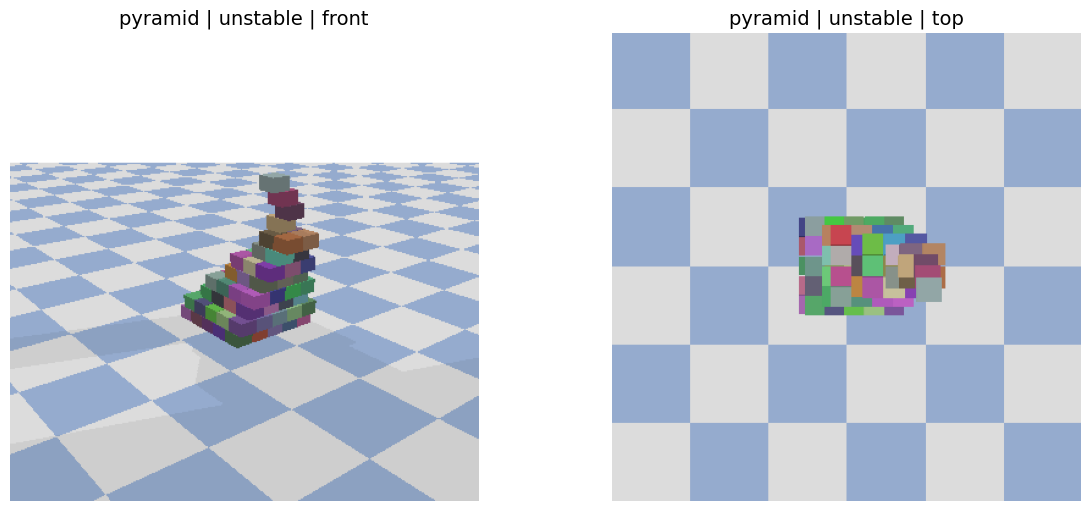

In [63]:
# Focused preview sandbox
STRUCTURE = 'pyramid'
STABILITY = 'unstable'
SEED = 123

show_layout_debug(STRUCTURE, STABILITY, seed=SEED);